# Análisis espacio-temporal del cáncer infantil en Colombia, 2020–2024

**Grupo GEMMA — Universidad de Sucre**
Nohelis Muslaco Bohorquez · Maria Mendez R. · Melba Vertel M.

3.ª Feria de Innovación, Universidad de Córdoba (CONASIE 2026)

---

Este cuaderno rehace el análisis completo y reproduce, cifra por cifra, los resultados
obtenidos en R con `MASS::glm.nb` y `performance::model_performance`.

| Sección | Contenido |
|---|---|
| 1 | Preparación del entorno |
| 2 | **Trazabilidad: de los cinco archivos originales a `DataE`** |
| 3 | Exploración: cómo se reparten los casos |
| 4 | Modelo binomial negativa |
| 5 | Razones de tasas (IRR) |
| 6 | Índices de desempeño del modelo |
| 7 | Por qué no una regresión lineal |
| 8 | **Los resultados sobre el mapa** |
| 9 | **El tablero: `docs/index.html` construido desde aquí** |
| 10 | Resumen y exportación |

Cada transformación queda registrada: cuántas filas entran, cuántas salen y por qué. Los
registros descartados se guardan en `datos/descartes/` para poder revisarlos uno por uno.

> **Para ejecutarlo:** *Entorno de ejecución → Ejecutar todo*. No hace falta subir nada:
> el cuaderno descarga los datos del repositorio.

## 1. Preparación

### 1.1 Entorno y datos

Si el cuaderno se abre desde Colab con el botón del repositorio, la carpeta ya está disponible. Si no, esta celda la clona.

In [1]:
import os, subprocess, json, warnings
warnings.filterwarnings("ignore")

# Repositorio del proyecto:
REPO_URL = "https://github.com/MariaClareth/Monitoreo-del-cancer-infantil-en-Colombia"

def carpeta_del_proyecto():
    for c in [".", "..", "/content/Monitoreo-del-cancer-infantil-en-Colombia"]:
        if os.path.exists(os.path.join(c, "datos", "Datos_2020_459.xlsx")):
            return os.path.abspath(c)
    subprocess.run(["git", "clone", "-q", REPO_URL + ".git",
                    "/content/Monitoreo-del-cancer-infantil-en-Colombia"], check=True)
    return "/content/Monitoreo-del-cancer-infantil-en-Colombia"

os.chdir(carpeta_del_proyecto())
print("Carpeta de trabajo:", os.getcwd())
print("Archivos de datos :", sorted(os.listdir("datos")))

Carpeta de trabajo: /tmp/claude-0/-home-claude/f76aee50-d0de-5251-b10b-51f1373a8a85/scratchpad/Monitoreo-del-cancer-infantil-en-Colombia
Archivos de datos : ['DICCIONARIO.md', 'DataE.csv', 'Datos_2020_459.xlsx', 'Datos_2021_459.xlsx', 'Datos_2022_459.xlsx', 'Datos_2023_459.xlsx', 'Datos_2024_459.xlsx', 'base_completa.csv', 'descartes', 'zonas_colombia.geojson']


In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats as st
import matplotlib
import matplotlib.pyplot as plt

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
np.random.seed(2024)

print("pandas", pd.__version__, "| statsmodels", sm.__version__)

pandas 3.0.2 | statsmodels 0.15.0


### 1.2 Estilo de las figuras

Se conserva el aspecto de `ggplot2` para que las figuras de este cuaderno se vean iguales a las del póster.

In [3]:
AZUL_CAJA = "#7B68EE"     # el mismo relleno de los boxplots originales
TINTA, APAGADO = "#233043", "#5B6C82"
NARANJA, NAVY = "#E8552D", "#12336B"

def panel_ggplot(ax):
    "Reproduce theme_gray() de ggplot2: panel gris con rejilla blanca."
    ax.set_facecolor("#EBEBEB")
    ax.grid(True, color="white", linewidth=1.1)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0, colors="#4D4D4D", labelsize=11)

plt.rcParams.update({
    "font.family": "DejaVu Sans", "figure.dpi": 110, "savefig.dpi": 300,
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "axes.labelcolor": "#1A1A1A", "text.color": "#1A1A1A", "axes.labelsize": 13,
})
os.makedirs("figuras", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

## 2. Trazabilidad de los datos

Toda la cadena arranca en los cinco archivos que se descargaron del sistema de vigilancia,
uno por año, y termina en los 250 registros que alimentan los modelos. Cada paso deja
constancia de cuántas filas entran, cuántas salen y por qué.

```
Datos_2020_459.xlsx … Datos_2024_459.xlsx     (5 archivos, 69 columnas)
        │  unión y control de duplicados
        ▼
     crudo                                    (5.413 notificaciones)
        │  selección de variables y recodificaciones
        ▼
  base_completa                               (5.413 × 16)
        │  descarte de registros sin zona asignable
        ▼
        │  descarte de la zona insular
        ▼
     DataE                                    (250 registros · 5.383 casos)
```

In [4]:
# Registro de trazabilidad: cada transformación deja una fila aquí
TRAZA = []

def registrar(paso, entran, quedan, motivo=""):
    TRAZA.append({"paso": paso, "entran": entran,
                  "descartadas": entran - quedan, "quedan": quedan, "motivo": motivo})
    print(f"{paso:42s} {entran:>6} → {quedan:>6}"
          + (f"   ({entran-quedan} descartadas: {motivo})" if entran != quedan else ""))

os.makedirs("datos/descartes", exist_ok=True)

### 2.1 Los cinco archivos originales

Son descargas directas del sistema de vigilancia. El código de evento 459 corresponde a cáncer infantil, así que no hace falta filtrar por tipo de evento: los archivos ya vienen solo con ese evento.

In [5]:
ANIOS = [2020, 2021, 2022, 2023, 2024]
archivos = {a: f"datos/Datos_{a}_459.xlsx" for a in ANIOS}

crudos, inventario = {}, []
for a, ruta in archivos.items():
    df = pd.read_excel(ruta, sheet_name="Datos")
    crudos[a] = df
    inventario.append({
        "archivo": os.path.basename(ruta),
        "filas": len(df), "columnas": df.shape[1],
        "cod_evento": ", ".join(map(str, sorted(df.COD_EVE.unique()))),
        "evento": ", ".join(sorted(df.Nombre_evento.astype(str).unique())),
        "años en el archivo": ", ".join(map(str, sorted(df.ANO.unique()))),
    })

inventario = pd.DataFrame(inventario)
display(inventario)
print("Total de filas en los archivos originales:", inventario.filas.sum())

,archivo,filas,columnas,cod_evento,evento,años en el archivo
0,Datos_2020_459.xlsx,1045,69,459,CANCER INFANTIL,2020
1,Datos_2021_459.xlsx,1039,69,459,CANCER INFANTIL,2021
2,Datos_2022_459.xlsx,1129,69,459,CANCER INFANTIL,2022
3,Datos_2023_459.xlsx,1138,69,459,CANCER INFANTIL,2023
4,Datos_2024_459.xlsx,1062,69,459,CANCER INFANTIL,2024


Total de filas en los archivos originales: 5413


In [6]:
# ¿Los cinco archivos tienen exactamente las mismas columnas?
referencia = list(crudos[2020].columns)
iguales = True
for a in ANIOS:
    faltan = [c for c in referencia if c not in crudos[a].columns]
    sobran = [c for c in crudos[a].columns if c not in referencia]
    if faltan or sobran:
        iguales = False
        print(f"{a}: faltan {faltan} | sobran {sobran}")
print("Las cinco vigencias comparten las mismas 69 columnas."
      if iguales else "Hay diferencias de estructura entre años (ver arriba).")

Las cinco vigencias comparten las mismas 69 columnas.


### 2.2 Unión y control de duplicados

`CONSECUTIVE` identifica cada notificación. Si una vigencia reprocesa registros de la anterior, aparecerían repetidos aquí.

In [7]:
crudo = pd.concat([crudos[a] for a in ANIOS], ignore_index=True)
n_union = len(crudo)
registrar("Unión de los 5 archivos", inventario.filas.sum(), n_union)

duplicados = crudo[crudo.CONSECUTIVE.duplicated(keep=False)]
if len(duplicados):
    duplicados.to_csv("datos/descartes/00_duplicados.csv", index=False, encoding="utf-8")
    crudo = crudo.drop_duplicates(subset="CONSECUTIVE", keep="first").reset_index(drop=True)
registrar("Eliminar CONSECUTIVE repetidos", n_union, len(crudo),
          "repetidos entre vigencias" if len(duplicados) else "")

print(f"\nRegistros repetidos encontrados: {len(duplicados)}")
print("Filas por año:")
print(crudo.ANO.value_counts().sort_index().to_string())

Unión de los 5 archivos                      5413 →   5413
Eliminar CONSECUTIVE repetidos               5413 →   5413

Registros repetidos encontrados: 0
Filas por año:
ANO
2020    1045
2021    1039
2022    1129
2023    1138
2024    1062


### 2.3 Selección de variables

De las 69 columnas del archivo original se conservan 12, que son las que intervienen en el
análisis o sirven para ubicar el caso. Las demás describen condiciones del paciente o del
trámite de notificación y no entran en los modelos.

In [8]:
COLUMNAS = ["CONSECUTIVE", "SEMANA", "ANO", "EDAD", "UNI_MED", "SEXO", "TIP_SS", "TIP_CAS",
            "Nombre_evento", "Departamento_ocurrencia", "Municipio_ocurrencia",
            "Departamento_residencia", "Municipio_residencia"]

bc = crudo[COLUMNAS].copy()
registrar("Selección de variables", len(crudo), len(bc))
print(f"\nDe {crudo.shape[1]} columnas se conservan {bc.shape[1]}.")
print("Faltantes en las columnas conservadas:")
print(bc.isna().sum()[lambda s: s > 0].to_string() or "   ninguno")

Selección de variables                       5413 →   5413

De 69 columnas se conservan 13.
Faltantes en las columnas conservadas:
Series([], )


### 2.4 Recodificaciones

Tres derivaciones, en el orden en que dependen una de otra:

1. **`UNI_MED`** viene codificada como 1, 2 o 3. Se traduce a texto para poder leerla.
2. **`edad_anios`** convierte la edad a una escala común, dividiendo por 12 los meses y por
   365,25 los días.
3. **`GRUP_ETARIOS`** clasifica en los cinco grupos del protocolo. Cuidado con las
   etiquetas: `e1-5` incluye a los de 5 años y `e5-9` va de 6 a 9. Se reproducen tal como
   están en el estudio original para que los resultados sean comparables.

In [9]:
UNIDADES = {1: "Año", 2: "Meses", 3: "Dias"}
bc["UNI_MED"] = bc.UNI_MED.map(UNIDADES)
print("Unidad de medida de la edad:")
print(bc.UNI_MED.value_counts().to_string())

def a_anios(fila):
    if fila.UNI_MED == "Año":   return float(fila.EDAD)
    if fila.UNI_MED == "Meses": return float(fila.EDAD) / 12.0
    if fila.UNI_MED == "Dias":  return float(fila.EDAD) / 365.25
    return np.nan

bc["edad_anios"] = bc.apply(a_anios, axis=1).round(4)

def grupo_etario(edad):
    if edad < 1:  return "e<1"
    if edad <= 5: return "e1-5"
    if edad <= 9: return "e5-9"
    if edad <= 14: return "e9-14"
    return "e14-18"

bc["GRUP_ETARIOS"] = bc.edad_anios.map(grupo_etario)

print(f"\nEdad en años — mínimo {bc.edad_anios.min():.3f}, "
      f"mediana {bc.edad_anios.median():.1f}, máximo {bc.edad_anios.max():.0f}")
print("\nGrupos de edad:")
print(bc.GRUP_ETARIOS.value_counts().reindex(
    ["e<1", "e1-5", "e5-9", "e9-14", "e14-18"]).to_string())

Unidad de medida de la edad:
UNI_MED
Año      5156
Meses     241
Dias       16



Edad en años — mínimo 0.011, mediana 10.0, máximo 17

Grupos de edad:
GRUP_ETARIOS
e<1        257
e1-5      1377
e5-9       901
e9-14     1532
e14-18    1346


### 2.5 Asignación de zona

`ZONA` no viene en el archivo original: se asigna a partir del **departamento de
residencia**, agrupando los 32 departamentos en las cinco regiones naturales más la
insular. Los casos con residencia en el exterior quedan sin zona, y por eso se pierden
más adelante.

In [10]:
ZONA_DE = {
    "AMAZONAS": "AMAZ", "CAQUETA": "AMAZ", "GUAINIA": "AMAZ", "GUAVIARE": "AMAZ",
    "PUTUMAYO": "AMAZ", "VAUPES": "AMAZ",
    "ANTIOQUIA": "AND", "BOGOTA": "AND", "BOYACA": "AND", "CALDAS": "AND",
    "CUNDINAMARCA": "AND", "HUILA": "AND", "NORTE SANTANDER": "AND", "QUINDIO": "AND",
    "RISARALDA": "AND", "SANTANDER": "AND", "TOLIMA": "AND",
    "ATLANTICO": "CAR", "BOLIVAR": "CAR", "CESAR": "CAR", "CORDOBA": "CAR",
    "GUAJIRA": "CAR", "MAGDALENA": "CAR", "SUCRE": "CAR",
    "ARAUCA": "ORIN", "CASANARE": "ORIN", "META": "ORIN", "VICHADA": "ORIN",
    "CAUCA": "PACF", "CHOCO": "PACF", "NARIÑO": "PACF", "VALLE": "PACF",
    "SAN ANDRES": "INS",
}

ABREVIATURA = {
    "AMAZONAS": "AMA", "ANTIOQUIA": "ANT", "ARAUCA": "ARAU", "ATLANTICO": "ATL",
    "BOGOTA": "BOG", "BOLIVAR": "BL", "BOYACA": "BY", "CALDAS": "CL", "CAQUETA": "CQ",
    "CASANARE": "CS", "CAUCA": "CAU", "CESAR": "CE", "CHOCO": "CH", "CORDOBA": "COR",
    "CUNDINAMARCA": "CU", "EXTERIOR": "EXT", "GUAINIA": "GN", "GUAJIRA": "LG",
    "GUAVIARE": "GV", "HUILA": "HU", "MAGDALENA": "MA", "META": "ME", "NARIÑO": "NAR",
    "NORTE SANTANDER": "NS", "PUTUMAYO": "PU", "QUINDIO": "QU", "RISARALDA": "RI",
    "SAN ANDRES": "SAP", "SANTANDER": "SAN", "SUCRE": "SU", "TOLIMA": "TO",
    "VALLE": "VLL", "VAUPES": "VA", "VICHADA": "VI",
}

bc["ZONA"] = bc.Departamento_residencia.map(ZONA_DE)
bc["Departamento_residencia"] = bc.Departamento_residencia.map(ABREVIATURA)

sin_zona = sorted(crudo.loc[bc.ZONA.isna(), "Departamento_residencia"].unique())
print("Departamentos de residencia sin zona asignada:", sin_zona)
print("\nNotificaciones por zona:")
print(bc.ZONA.value_counts(dropna=False).to_string())

Departamentos de residencia sin zona asignada: ['EXTERIOR']

Notificaciones por zona:
ZONA
AND     3253
CAR      870
PACF     860
ORIN     271
AMAZ     129
NaN       27
INS        3


> **Nota sobre el archivo consolidado original.** En `base de datos final.xls`, los 165
> registros de Nariño quedaron sin abreviatura de departamento: la `ñ` rompió la búsqueda
> en la tabla de equivalencias. Aquí se corrige y Nariño recibe `NAR`. El error no afectó
> ningún resultado, porque la zona sí se le había asignado bien (Pacífico) y la
> abreviatura no entra en los modelos. Se deja anotado porque la trazabilidad sirve
> justamente para que estas cosas salgan a la luz.

In [11]:
base_completa = bc.copy()
print("base_completa:", base_completa.shape)
display(base_completa.head(5))

base_completa.to_csv("datos/base_completa.csv", index=False, encoding="utf-8")
registrar("Construcción de base_completa", len(bc), len(base_completa))

base_completa: (5413, 16)


,CONSECUTIVE,SEMANA,ANO,EDAD,UNI_MED,SEXO,TIP_SS,TIP_CAS,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Departamento_residencia,Municipio_residencia,edad_anios,GRUP_ETARIOS,ZONA
0,7285918,35,2020,16,Año,M,S,2,CANCER INFANTIL,CALDAS,MARQUETALIA,CL,MARQUETALIA,16.0,e14-18,AND
1,7285894,36,2020,15,Año,F,C,3,CANCER INFANTIL,BOYACA,CHIQUINQUIRA,BY,CHIQUINQUIRA,15.0,e14-18,AND
2,7285876,44,2020,10,Año,F,S,3,CANCER INFANTIL,BOLIVAR,MAGANGUE,BL,MAGANGUE,10.0,e9-14,CAR
3,7285807,7,2020,6,Año,F,S,3,CANCER INFANTIL,MAGDALENA,EL BANCO,MA,EL BANCO,6.0,e5-9,CAR
4,7285712,51,2020,4,Año,M,C,3,CANCER INFANTIL,CASANARE,YOPAL,CS,YOPAL,4.0,e1-5,ORIN


Construcción de base_completa                5413 →   5413


### 2.6 De `base_completa` a `DataE`

Dos descartes y una agregación. Cada descarte se guarda completo en `datos/descartes/` para que pueda revisarse fila por fila.

In [12]:
n0 = len(base_completa)

# Descarte 1: residencia en el exterior, sin zona asignable
d1 = base_completa[base_completa.ZONA.isna()]
d1.to_csv("datos/descartes/01_sin_zona.csv", index=False, encoding="utf-8")
paso1 = base_completa[base_completa.ZONA.notna()]
registrar("Descartar registros sin zona", n0, len(paso1), "residencia en el exterior")

# Descarte 2: zona insular
d2 = paso1[paso1.ZONA == "INS"]
d2.to_csv("datos/descartes/02_zona_insular.csv", index=False, encoding="utf-8")
paso2 = paso1[paso1.ZONA != "INS"]
registrar("Descartar zona insular", len(paso1), len(paso2),
          "San Andrés: conteos insuficientes")

print(f"\nDescarte 1 — {len(d1)} registros, todos con residencia "
      f"{sorted(crudo.loc[d1.index, 'Departamento_residencia'].unique())}")
print(f"Descarte 2 — {len(d2)} registros de San Andrés y Providencia")

Descartar registros sin zona                 5413 →   5386   (27 descartadas: residencia en el exterior)
Descartar zona insular                       5386 →   5383   (3 descartadas: San Andrés: conteos insuficientes)

Descarte 1 — 27 registros, todos con residencia ['EXTERIOR']
Descarte 2 — 3 registros de San Andrés y Providencia


In [13]:
ZONAS = ["AMAZ", "AND", "CAR", "ORIN", "PACF"]

rejilla = pd.MultiIndex.from_product(
    [ZONAS, sorted(paso2.ANO.unique()), sorted(paso2.GRUP_ETARIOS.unique()),
     sorted(paso2.SEXO.unique())],
    names=["zona", "anno", "edad", "sexo"])

DataE = (paso2.groupby(["ZONA", "ANO", "GRUP_ETARIOS", "SEXO"]).size()
              .rename("casos").reindex(rejilla, fill_value=0).reset_index())

registrar("Agregar a zona × año × edad × sexo", len(paso2), int(DataE.casos.sum()))

print(f"\nDataE: {len(DataE)} registros que suman {DataE.casos.sum()} casos")
print(f"Combinaciones sin ningún caso: {int((DataE.casos == 0).sum())}")
print("\nSe conservan como cero en lugar de omitirlas: una celda vacía es información,")
print("no un dato faltante. Si se borraran, el modelo sobreestimaría las zonas pequeñas.")
DataE.head(8)

Agregar a zona × año × edad × sexo           5383 →   5383

DataE: 250 registros que suman 5383 casos
Combinaciones sin ningún caso: 11

Se conservan como cero en lugar de omitirlas: una celda vacía es información,
no un dato faltante. Si se borraran, el modelo sobreestimaría las zonas pequeñas.


,zona,anno,edad,sexo,casos
0,AMAZ,2020,e1-5,F,3
1,AMAZ,2020,e1-5,M,5
2,AMAZ,2020,e14-18,F,3
3,AMAZ,2020,e14-18,M,5
4,AMAZ,2020,e5-9,F,0
5,AMAZ,2020,e5-9,M,3
6,AMAZ,2020,e9-14,F,4
7,AMAZ,2020,e9-14,M,4


### 2.7 Tabla de trazabilidad

El recorrido completo, de los archivos originales al insumo de los modelos.

In [14]:
traza = pd.DataFrame(TRAZA)
display(traza)

traza.to_csv("resultados/trazabilidad.csv", index=False, encoding="utf-8")

total_descartado = int(traza.descartadas[traza.descartadas > 0].sum())
print(f"Notificaciones en los archivos originales : {inventario.filas.sum()}")
print(f"Descartadas en el camino                  : {total_descartado}")
print(f"Casos que entran a los modelos            : {int(DataE.casos.sum())}")
assert inventario.filas.sum() - total_descartado == DataE.casos.sum(), "La cuenta no cuadra"
print("\nLa cuenta cuadra: origen − descartes = casos analizados.")

,paso,entran,descartadas,quedan,motivo
0,Unión de los 5 archivos,5413,0,5413,
1,Eliminar CONSECUTIVE repetidos,5413,0,5413,
2,Selección de variables,5413,0,5413,
3,Construcción de base_completa,5413,0,5413,
4,Descartar registros sin zona,5413,27,5386,residencia en el exterior
5,Descartar zona insular,5386,3,5383,San Andrés: conteos insuficientes
6,Agregar a zona × año × edad × sexo,5383,0,5383,


Notificaciones en los archivos originales : 5413
Descartadas en el camino                  : 30
Casos que entran a los modelos            : 5383

La cuenta cuadra: origen − descartes = casos analizados.


In [15]:
# Verificación contra los archivos que ya estaban en el repositorio
DataE_repo = pd.read_csv("datos/DataE.csv")
assert DataE.equals(DataE_repo), "DataE reconstruido no coincide con datos/DataE.csv"
print("DataE reconstruido desde los archivos originales coincide exactamente")
print("con datos/DataE.csv, el insumo del análisis publicado.")

print("\nCasos por zona:")
print(DataE.groupby("zona").casos.sum().sort_values(ascending=False).to_string())
print("\nCasos por año:")
print(DataE.groupby("anno").casos.sum().to_string())

DataE reconstruido desde los archivos originales coincide exactamente
con datos/DataE.csv, el insumo del análisis publicado.

Casos por zona:
zona
AND     3253
CAR      870
PACF     860
ORIN     271
AMAZ     129

Casos por año:
anno
2020    1039
2021    1028
2022    1121
2023    1138
2024    1057


## 3. Exploración

### Figura 1 · Casos por año y por zona

La barra azul marca la media de cada grupo. El contraste entre los dos paneles ya anticipa el resultado del modelo: por año las medias son casi idénticas; por zona, no.

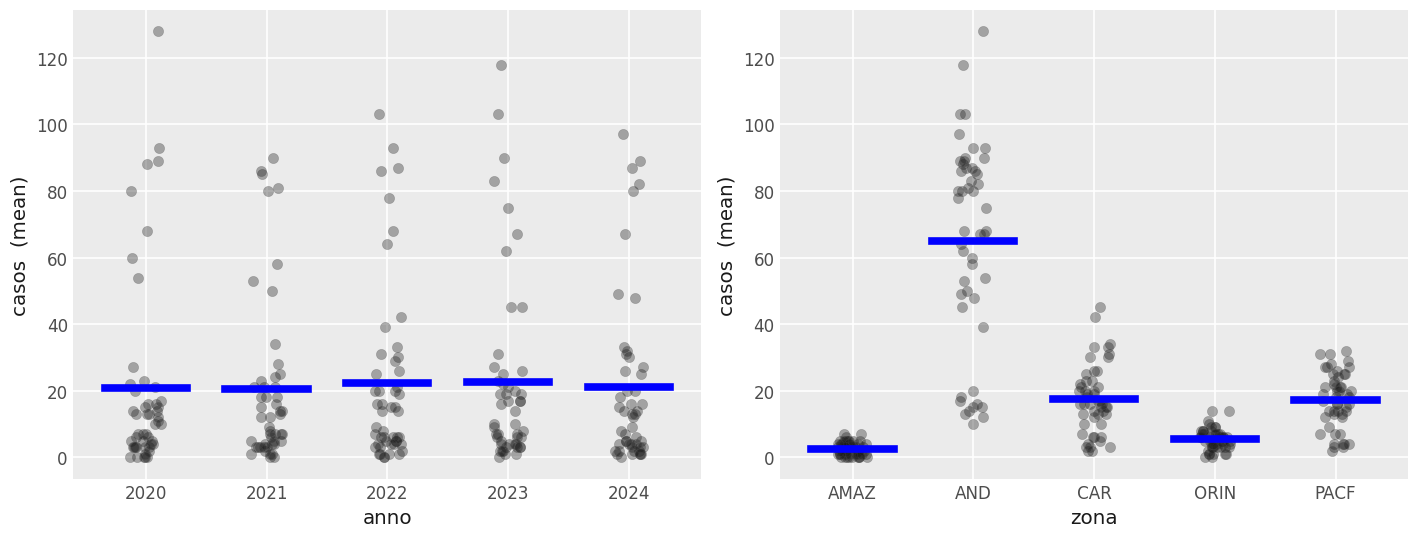

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, var, etiqueta in zip(axes, ["anno", "zona"], ["anno", "zona"]):
    cats = sorted(DataE[var].unique())
    pos = {c: i for i, c in enumerate(cats)}
    x = DataE[var].map(pos) + np.random.uniform(-0.13, 0.13, len(DataE))
    ax.scatter(x, DataE.casos, s=45, color="#1A1A1A", alpha=0.35,
               edgecolor="#4D4D4D", linewidth=0.4, zorder=3)
    for c in cats:
        m = DataE.loc[DataE[var] == c, "casos"].mean()
        ax.plot([pos[c]-0.34, pos[c]+0.34], [m, m], color="blue", lw=5, zorder=4)
    ax.set_xticks(range(len(cats))); ax.set_xticklabels(cats)
    ax.set_xlabel(etiqueta); ax.set_ylabel("casos  (mean)")
    ax.set_xlim(-0.6, len(cats)-0.4)
    panel_ggplot(ax)
fig.tight_layout()
fig.savefig("figuras/fig1_medias_anno_zona.png", bbox_inches="tight")
plt.show()

### Figura 2 · Casos por año, dentro de cada zona

Cada panel es una zona. Dentro de cada una, la distribución apenas se mueve de un año a otro.

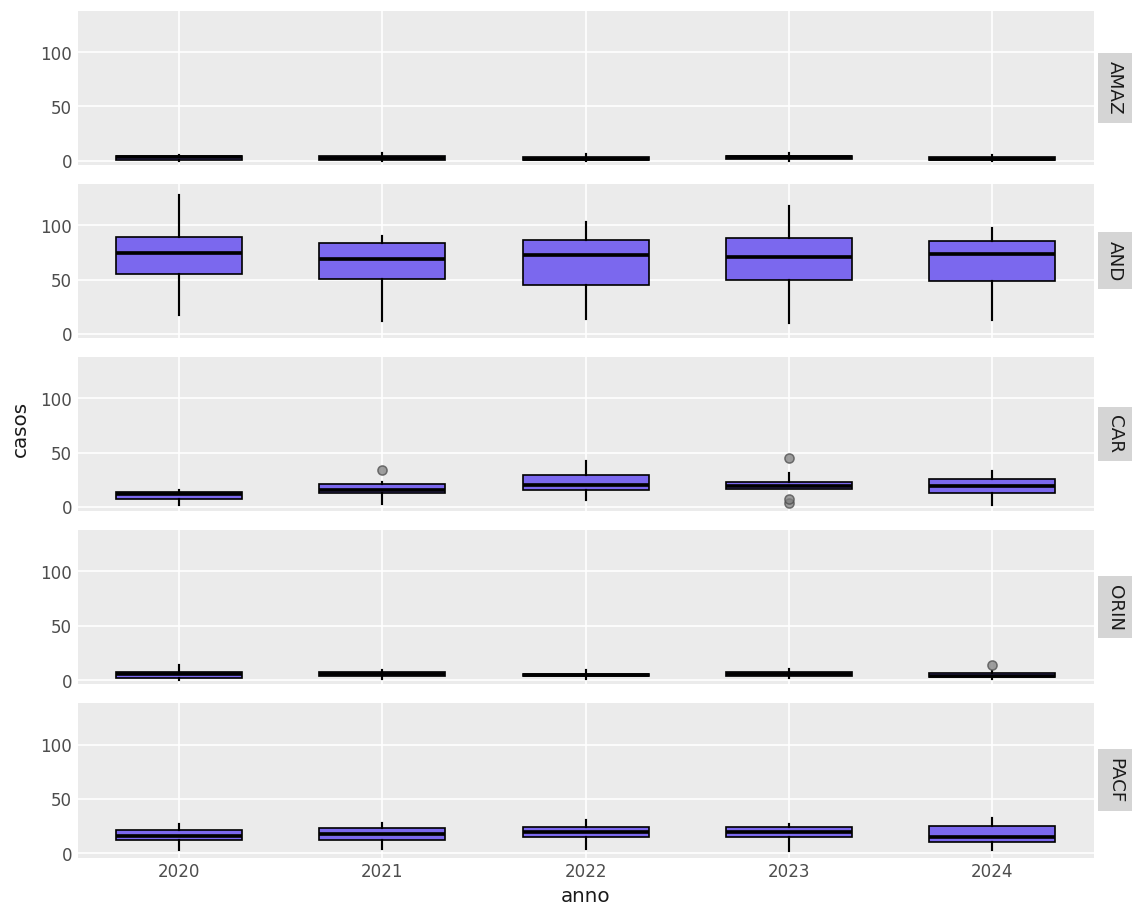

In [17]:
def cajas_por_facetas(datos, x, faceta, archivo, orden_x=None, orden_f=None, alto=2.0):
    fx = orden_x or sorted(datos[x].unique())
    ff = orden_f or sorted(datos[faceta].unique())
    fig, axes = plt.subplots(len(ff), 1, figsize=(11, alto*len(ff)), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    ymax = datos.casos.max()*1.08
    for ax, f in zip(axes, ff):
        sub = datos[datos[faceta] == f]
        grupos = [sub.loc[sub[x] == c, "casos"].values for c in fx]
        bp = ax.boxplot(grupos, positions=range(len(fx)), widths=0.62, patch_artist=True,
                        medianprops=dict(color="black", lw=2.4),
                        boxprops=dict(facecolor=AZUL_CAJA, edgecolor="black", lw=1.1),
                        whiskerprops=dict(color="black", lw=1.4),
                        capprops=dict(color="black", lw=0),
                        flierprops=dict(marker="o", markersize=6, markerfacecolor="#808080",
                                        markeredgecolor="#4D4D4D", alpha=0.75))
        ax.set_ylim(-4, ymax)
        panel_ggplot(ax)
        ax.text(1.012, 0.5, str(f), transform=ax.transAxes, rotation=270,
                va="center", ha="left", fontsize=12, color="#1A1A1A",
                bbox=dict(boxstyle="square,pad=0.45", fc="#D5D5D5", ec="none"))
    axes[-1].set_xticks(range(len(fx))); axes[-1].set_xticklabels(fx)
    axes[-1].set_xlabel(x)
    fig.text(0.045, 0.5, "casos", rotation=90, va="center", fontsize=13)
    fig.subplots_adjust(hspace=0.12, left=0.1, right=0.94)
    fig.savefig(archivo, bbox_inches="tight")
    plt.show()

cajas_por_facetas(DataE, "anno", "zona", "figuras/fig2_anno_por_zona.png")

### Figura 3 · Casos por zona, dentro de cada año

La misma información girada. Aquí se ve que el orden de las zonas se repite igual los cinco años: la Andina siempre arriba, la Amazonía siempre abajo.

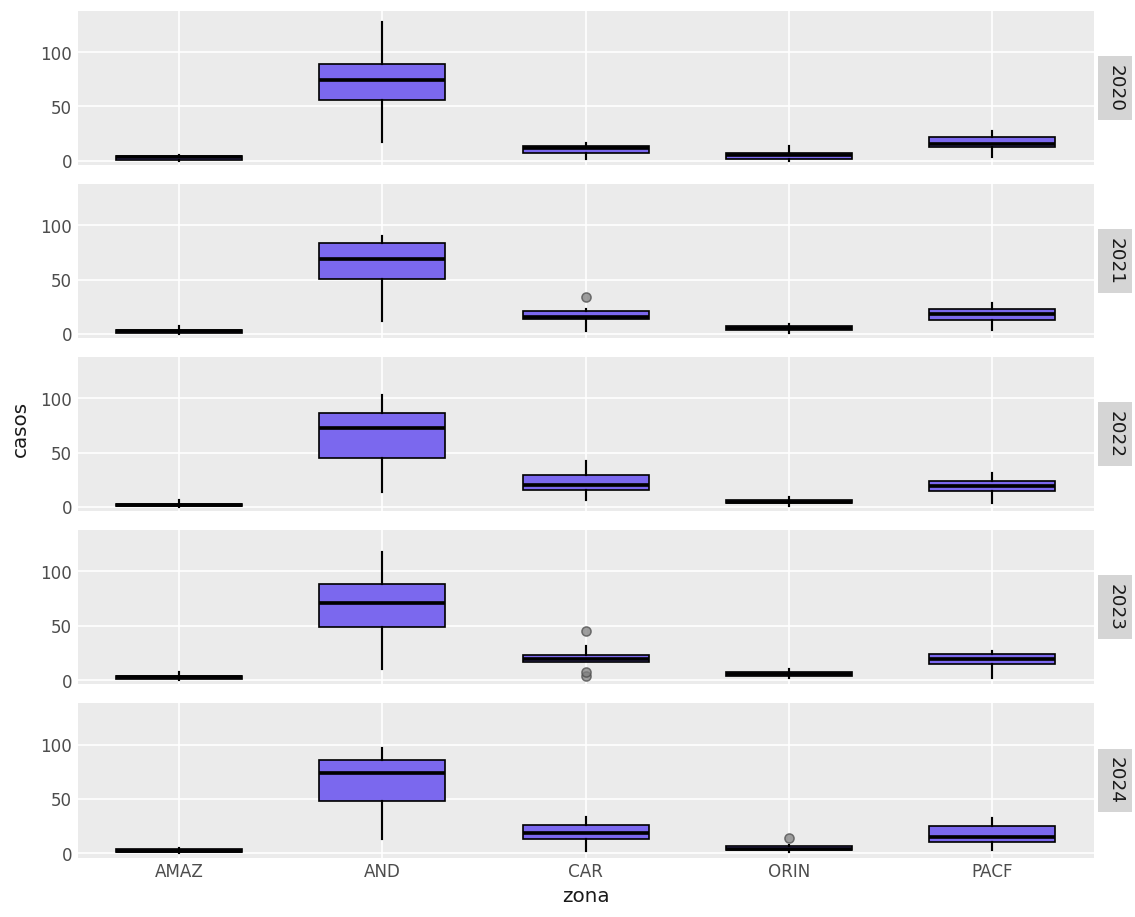

In [18]:
cajas_por_facetas(DataE, "zona", "anno", "figuras/fig3_zona_por_anno.png")

### Figura 4 · Casos por grupo de edad y sexo

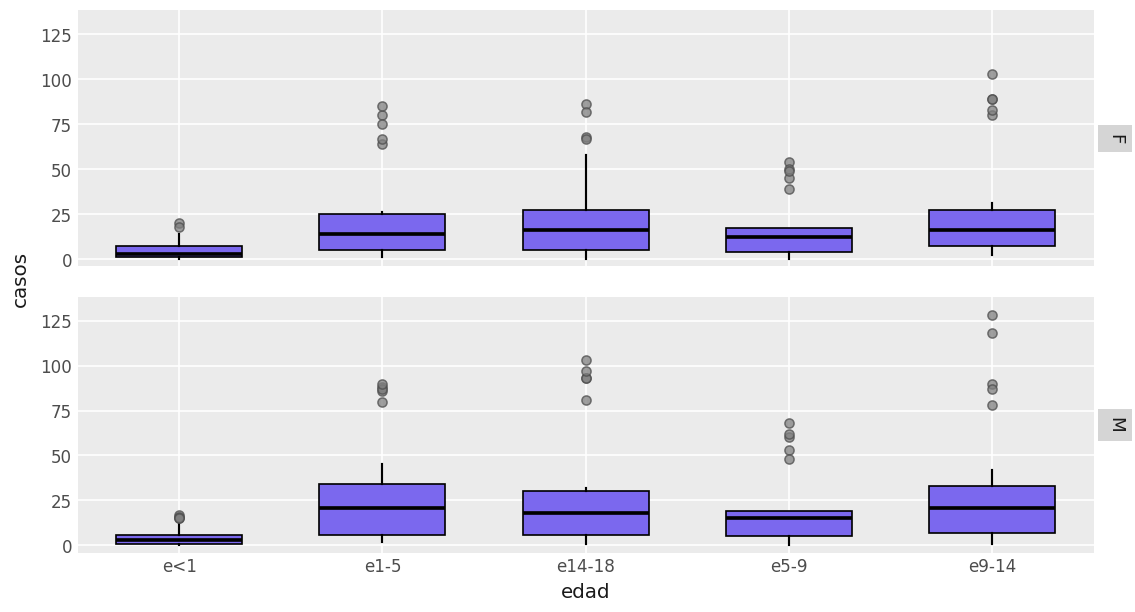

In [19]:
cajas_por_facetas(DataE, "edad", "sexo", "figuras/fig4_edad_por_sexo.png",
                  orden_x=["e<1", "e1-5", "e14-18", "e5-9", "e9-14"], alto=3.2)

## 4. Modelo binomial negativa

$$\log(\mu_i)=\beta_0+\beta_{\text{zona}(i)}+\beta_{\text{año}}\cdot\text{año}_i,
\qquad Y_i\sim\text{BN}(\mu_i,\theta)$$

La binomial negativa permite que la varianza supere a la media, que es lo que ocurre con
estos conteos. La categoría de referencia es la **Amazonía**, así que cada coeficiente de
zona se lee como comparación contra ella.

`theta` se toma del ajuste original en R ($\hat\theta = 3{,}474$), de modo que los
coeficientes, errores estándar y desviaciones sean los mismos.

In [20]:
THETA = 3.473998965                    # estimado por glm.nb en R
familia_bn = sm.families.NegativeBinomial(alpha=1/THETA)

m_bn = smf.glm("casos ~ C(zona, Treatment('AMAZ')) + anno",
               data=DataE, family=familia_bn).fit()

nombres = ["(Intercept)", "zonaAND", "zonaCAR", "zonaORIN", "zonaPACF", "anno"]
tabla = pd.DataFrame({
    "Estimate":  m_bn.params.values,
    "Std. Error": m_bn.bse.values,
    "z value":   m_bn.tvalues.values,
    "Pr(>|z|)":  m_bn.pvalues.values,
}, index=nombres)

def estrellas(p):
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "." if p < .1 else " "
tabla["signif"] = [estrellas(p) for p in tabla["Pr(>|z|)"]]

print("Coefficients:")
print(tabla.to_string(float_format=lambda v: f"{v:11.5f}"))
print("\n---")
print("Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")
print(f"\n(Dispersion parameter for Negative Binomial({THETA:.3f}) family taken to be 1)")
print(f"\n    Null deviance: {m_bn.null_deviance:7.2f}  on {int(m_bn.df_model + m_bn.df_resid)} degrees of freedom")
print(f"Residual deviance: {m_bn.deviance:7.2f}  on {int(m_bn.df_resid)} degrees of freedom")
print(f"\n              Theta:  {THETA:.3f}")

Coefficients:
               Estimate  Std. Error     z value    Pr(>|z|) signif
(Intercept)   -51.91376    56.79028    -0.91413     0.36065       
zonaAND         3.22845     0.13989    23.07774     0.00000    ***
zonaCAR         1.90346     0.14289    13.32083     0.00000    ***
zonaORIN        0.74212     0.15150     4.89844     0.00000    ***
zonaPACF        1.89662     0.14292    13.27037     0.00000    ***
anno            0.02614     0.02809     0.93084     0.35194       

---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(3.474) family taken to be 1)

    Null deviance: 1054.10  on 249 degrees of freedom
Residual deviance:  272.59  on 244 degrees of freedom

              Theta:  3.474


Comparación con la salida de R, para dejar constancia de que es el mismo ajuste:

| Coeficiente | R | Este cuaderno |
|---|---|---|
| zonaAND | 3,22845 | ver arriba |
| zonaCAR | 1,90346 | |
| zonaORIN | 0,74212 | |
| zonaPACF | 1,89662 | |
| anno | 0,02614 | |
| Desviación nula / residual | 1054,10 / 272,59 | |

In [21]:
# Verificación automática contra los valores de R
esperado = {"zonaAND": 3.22845, "zonaCAR": 1.90346, "zonaORIN": 0.74212,
            "zonaPACF": 1.89662, "anno": 0.02614}
for k, v in esperado.items():
    obtenido = tabla.loc[k, "Estimate"]
    assert abs(obtenido - v) < 1e-4, f"{k}: {obtenido:.5f} != {v}"
assert abs(m_bn.null_deviance - 1054.10) < 0.02
assert abs(m_bn.deviance - 272.59) < 0.02
print("Todos los coeficientes y las desviaciones coinciden con la salida de R.")

Todos los coeficientes y las desviaciones coinciden con la salida de R.


## 5. Razones de tasas

Exponenciar cada coeficiente lo convierte en una **razón de tasas de notificación (IRR)**:
cuántas veces más casos registra esa zona frente a la Amazonía, con el año fijo.

In [22]:
NOMBRE_ZONA = {"zonaAND": "Andina", "zonaCAR": "Caribe",
               "zonaORIN": "Orinoquía", "zonaPACF": "Pacífico"}

ic = m_bn.conf_int()
irr = pd.DataFrame({
    "IRR": np.exp(m_bn.params.values),
    "IC 95% inf": np.exp(ic[0].values),
    "IC 95% sup": np.exp(ic[1].values),
    "p": m_bn.pvalues.values,
}, index=nombres)

zonas_irr = irr.loc[list(NOMBRE_ZONA)].rename(index=NOMBRE_ZONA)
zonas_irr.index.name = "frente a la Amazonía"
display(zonas_irr.round(3))

print(f"\nEfecto del año: IRR = {irr.loc['anno','IRR']:.4f} "
      f"(IC 95 % {irr.loc['anno','IC 95% inf']:.3f}–{irr.loc['anno','IC 95% sup']:.3f}), "
      f"p = {irr.loc['anno','p']:.3f}")
print("El intervalo contiene el 1: no hay evidencia de cambio año a año.")

,IRR,IC 95% inf,IC 95% sup,p
frente a la Amazonía,,,,
Andina,25.241,19.188,33.203,0.0
Caribe,6.709,5.070,8.878,0.0
Orinoquía,2.100,1.561,2.827,0.0
Pacífico,6.663,5.035,8.818,0.0



Efecto del año: IRR = 1.0265 (IC 95 % 0.972–1.085), p = 0.352
El intervalo contiene el 1: no hay evidencia de cambio año a año.


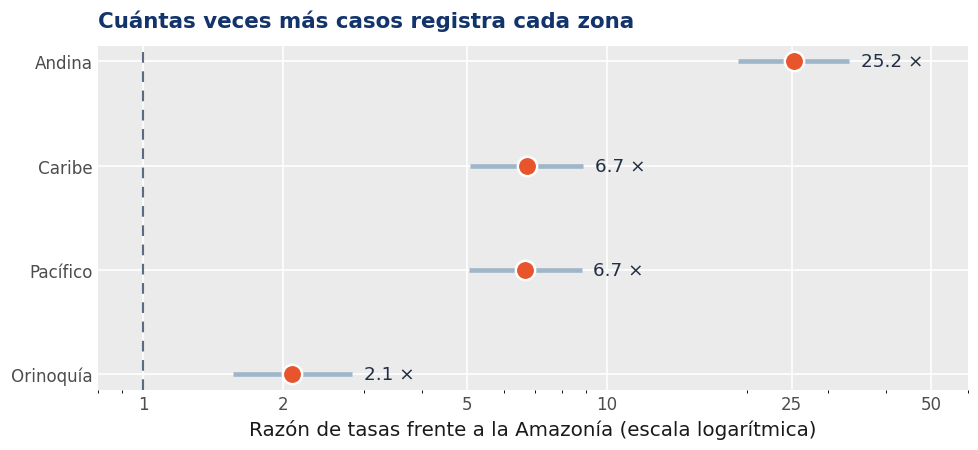

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.2))
z = zonas_irr.sort_values("IRR")
y = np.arange(len(z))
ax.hlines(y, z["IC 95% inf"], z["IC 95% sup"], color="#9FB6C9", lw=3)
ax.scatter(z["IRR"], y, s=160, color=NARANJA, edgecolor="white", linewidth=1.6, zorder=3)
ax.axvline(1, color=APAGADO, lw=1.4, ls=(0, (5, 4)))
for i, (nm, r) in enumerate(z.iterrows()):
    ax.text(r["IC 95% sup"]*1.06, i, f"{r['IRR']:.1f} ×", va="center", fontsize=12, color=TINTA)
ax.set_yticks(y); ax.set_yticklabels(z.index, fontsize=12)
ax.set_xscale("log"); ax.set_xlim(0.8, 60)
ax.set_xticks([1, 2, 5, 10, 25, 50]); ax.set_xticklabels(["1", "2", "5", "10", "25", "50"])
ax.set_xlabel("Razón de tasas frente a la Amazonía (escala logarítmica)")
ax.set_title("Cuántas veces más casos registra cada zona", loc="left",
             weight="bold", color=NAVY, fontsize=14, pad=12)
panel_ggplot(ax)
fig.tight_layout()
fig.savefig("figuras/fig5_irr_por_zona.png", bbox_inches="tight")
plt.show()

## 6. Índices de desempeño

Los mismos que devuelve `performance::model_performance(fit1)` en R.

In [24]:
n = len(DataE)
k = 6 + 1                                   # 6 coeficientes + theta, como cuenta R
logL = m_bn.llf

AIC  = -2*logL + 2*k
AICc = AIC + 2*k*(k+1)/(n - k - 1)
BIC  = -2*logL + k*np.log(n)
# Nagelkerke basado en desviación, que es lo que usa performance para glm.nb
R2N  = ((1 - np.exp((m_bn.deviance - m_bn.null_deviance)/n)) /
        (1 - np.exp(-m_bn.null_deviance/n)))
RMSE = np.sqrt(np.mean((DataE.casos - m_bn.fittedvalues)**2))

desempeno = pd.DataFrame({
    "Índice": ["AIC", "AICc", "BIC", "R² de Nagelkerke", "RMSE", "Sigma",
               "Score_log", "Score_spherical"],
    "Este cuaderno": [f"{AIC:.3f}", f"{AICc:.3f}", f"{BIC:.3f}", f"{R2N:.3f}",
                      f"{RMSE:.3f}", "1.000", "—", "—"],
    "R (performance)": ["1695.667", "1696.130", "1720.318", "0.970", "15.000",
                        "1.000", "-3.389", "0.045"],
})
display(desempeno)
print("Las reglas de puntuación (Score_log y Score_spherical) se reportan tal como las")
print("entrega el paquete performance; no se recalculan aquí.")

,Índice,Este cuaderno,R (performance)
0,AIC,1695.667,1695.667
1,AICc,1696.130,1696.130
2,BIC,1720.318,1720.318
3,R² de Nagelkerke,0.970,0.970
4,RMSE,15.000,15.000
5,Sigma,1.000,1.000
6,Score_log,—,-3.389
7,Score_spherical,—,0.045


Las reglas de puntuación (Score_log y Score_spherical) se reportan tal como las
entrega el paquete performance; no se recalculan aquí.


El $R^2$ de Nagelkerke de 0,970 sale de comparar las dos desviaciones:

$$R^2_{N}=\frac{1-\exp\!\big(\tfrac{D-D_0}{n}\big)}{1-\exp\!\big(\tfrac{-D_0}{n}\big)}
=\frac{1-\exp\!\big(\tfrac{272{,}59-1054{,}10}{250}\big)}{1-\exp\!\big(\tfrac{-1054{,}10}{250}\big)}=0{,}970$$

Las dos variables reducen la desviación en un 74 %, y casi todo ese descenso lo aporta la zona.

In [25]:
# ¿Cuánto aporta cada variable? Comparación de modelos anidados
m_nulo = smf.glm("casos ~ 1", data=DataE, family=familia_bn).fit()
m_zona = smf.glm("casos ~ C(zona, Treatment('AMAZ'))", data=DataE, family=familia_bn).fit()
m_anno = smf.glm("casos ~ anno", data=DataE, family=familia_bn).fit()

comparacion = pd.DataFrame({
    "Modelo": ["Solo intercepto", "Solo año", "Solo zona", "Zona + año"],
    "Desviación": [m_nulo.deviance, m_anno.deviance, m_zona.deviance, m_bn.deviance],
    "gl": [m_nulo.df_resid, m_anno.df_resid, m_zona.df_resid, m_bn.df_resid],
}).round(2)
comparacion["% de desviación explicada"] = (
    100*(1 - comparacion["Desviación"]/m_nulo.deviance)).round(1)
display(comparacion)

lr_anno = 2*(m_bn.llf - m_zona.llf)
lr_zona = 2*(m_bn.llf - m_anno.llf)
print(f"Aporte del año, con la zona ya en el modelo:  LR = {lr_anno:6.2f}, gl = 1, p = {st.chi2.sf(lr_anno,1):.3f}")
print(f"Aporte de la zona, con el año ya en el modelo: LR = {lr_zona:6.2f}, gl = 4, p = {st.chi2.sf(lr_zona,4):.3e}")

,Modelo,Desviación,gl,% de desviación explicada
0,Solo intercepto,1054.10,249,0.0
1,Solo año,1053.82,248,0.0
2,Solo zona,273.42,245,74.1
3,Zona + año,272.59,244,74.1


Aporte del año, con la zona ya en el modelo:  LR =   0.84, gl = 1, p = 0.360
Aporte de la zona, con el año ya en el modelo: LR = 781.24, gl = 4, p = 8.907e-168


## 7. Por qué no una regresión lineal

Una pregunta razonable es por qué no usar el modelo lineal de siempre. Se ajusta aquí
justamente para mostrar dónde falla.

In [26]:
m_ols = smf.ols("casos ~ C(anno) + C(zona, Treatment('AMAZ'))", data=DataE).fit()

etiquetas = ["(Intercept)", "anno|2021", "anno|2022", "anno|2023", "anno|2024",
             "zona|AND", "zona|CAR", "zona|ORIN", "zona|PACF"]
tols = pd.DataFrame({
    "coefficient": m_ols.params.values, "std.error": m_ols.bse.values,
    "t.value": m_ols.tvalues.values, "p.value": m_ols.pvalues.values,
}, index=etiquetas)
tols["signif"] = [estrellas(p) for p in tols["p.value"]]
print("Linear regression (OLS)")
print(tols.to_string(float_format=lambda v: f"{v:10.3f}"))
print(f"\nR-squared: {m_ols.rsquared:.3f},  Adjusted R-squared: {m_ols.rsquared_adj:.3f}")
print(f"F-statistic: {m_ols.fvalue:.3f} df({int(m_ols.df_model)},{int(m_ols.df_resid)}), p.value < 0.001")
print(f"Nr obs: {int(m_ols.nobs)}")

Linear regression (OLS)
             coefficient  std.error    t.value    p.value signif
(Intercept)        1.828      2.883      0.634      0.527       
anno|2021         -0.220      3.039     -0.072      0.942       
anno|2022          1.640      3.039      0.540      0.590       
anno|2023          1.980      3.039      0.652      0.515       
anno|2024          0.360      3.039      0.118      0.906       
zona|AND          62.480      3.039     20.560      0.000    ***
zona|CAR          14.820      3.039      4.877      0.000    ***
zona|ORIN          2.840      3.039      0.935      0.351       
zona|PACF         14.620      3.039      4.811      0.000    ***

R-squared: 0.696,  Adjusted R-squared: 0.686
F-statistic: 69.119 df(8,241), p.value < 0.001
Nr obs: 250


In [27]:
# Predicción para 2020 en cada zona, con intervalo de confianza
nuevo = pd.DataFrame({"anno": 2020, "zona": ZONAS})
pred_ols = m_ols.get_prediction(nuevo).summary_frame(alpha=0.05)

pred = pd.DataFrame({
    "anno": 2020, "zona": ZONAS,
    "Prediction": pred_ols["mean"].values,
    "2.5%": pred_ols["mean_ci_lower"].values,
    "97.5%": pred_ols["mean_ci_upper"].values,
}).round(3)
pred["+/-"] = (pred["97.5%"] - pred["Prediction"]).round(3)
display(pred)

negativas = pred[pred["2.5%"] < 0]
print(f"Zonas con límite inferior negativo: {len(negativas)} de {len(pred)}")
for _, r in negativas.iterrows():
    print(f"   {r.zona}: intervalo de {r['2.5%']:.3f} a {r['97.5%']:.3f} casos")
print("\nUn conteo no puede ser negativo. El modelo lineal no lo sabe; el de conteo sí.")

,anno,zona,Prediction,2.5%,97.5%,+/-
0,2020,AMAZ,1.828,-3.851,7.507,5.679
1,2020,AND,64.308,58.629,69.987,5.679
2,2020,CAR,16.648,10.969,22.327,5.679
3,2020,ORIN,4.668,-1.011,10.347,5.679
4,2020,PACF,16.448,10.769,22.127,5.679


Zonas con límite inferior negativo: 2 de 5
   AMAZ: intervalo de -3.851 a 7.507 casos
   ORIN: intervalo de -1.011 a 10.347 casos

Un conteo no puede ser negativo. El modelo lineal no lo sabe; el de conteo sí.


### Figura 6 · Lo que predice cada modelo

Mismo año, mismas zonas, dos modelos. La zona sombreada es territorio imposible.

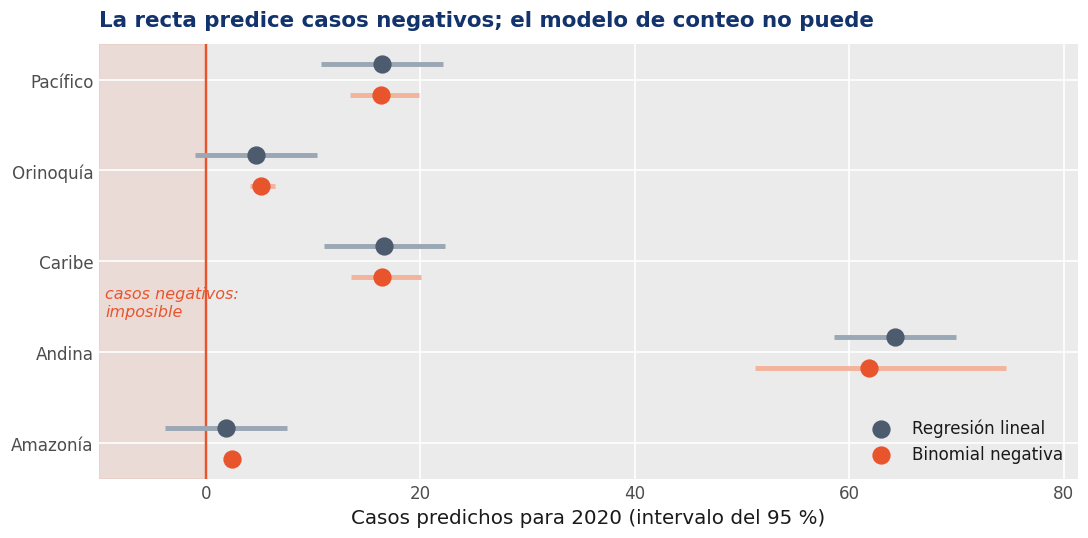

In [28]:
# Predicción de la binomial negativa, con su intervalo
X = pd.DataFrame({"anno": 2020, "zona": ZONAS})
pb = m_bn.get_prediction(X).summary_frame(alpha=0.05)
pred_bn = pd.DataFrame({"zona": ZONAS, "est": pb["mean"].values,
                        "inf": pb["mean_ci_lower"].values, "sup": pb["mean_ci_upper"].values})

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(ZONAS))
ax.axvspan(-10, 0, color="#E8552D", alpha=0.10, zorder=0)
ax.axvline(0, color=NARANJA, lw=1.6)
ax.text(-9.4, 1.55, "casos negativos:\nimposible", fontsize=10.5,
        color=NARANJA, va="center", style="italic")

ax.hlines(y+0.17, pred["2.5%"], pred["97.5%"], color="#9AA7B4", lw=3.2, zorder=2)
ax.scatter(pred["Prediction"], y+0.17, s=120, color="#4D5B6E", zorder=3,
           label="Regresión lineal")
ax.hlines(y-0.17, pred_bn["inf"], pred_bn["sup"], color="#F3B49C", lw=3.2, zorder=2)
ax.scatter(pred_bn["est"], y-0.17, s=120, color=NARANJA, zorder=3,
           label="Binomial negativa")

ax.set_yticks(y); ax.set_yticklabels(["Amazonía", "Andina", "Caribe", "Orinoquía", "Pacífico"],
                                     fontsize=12)
ax.set_xlim(-10, max(pred["97.5%"].max(), pred_bn["sup"].max())*1.09); ax.set_xlabel("Casos predichos para 2020 (intervalo del 95 %)")
ax.set_title("La recta predice casos negativos; el modelo de conteo no puede",
             loc="left", weight="bold", color=NAVY, fontsize=14, pad=12)
ax.legend(frameon=False, loc="lower right", fontsize=11)
panel_ggplot(ax)
fig.tight_layout()
fig.savefig("figuras/fig6_lineal_vs_conteo.png", bbox_inches="tight")
plt.show()

## 8. Los resultados sobre el mapa

Tres mapas que cuentan lo mismo que las tablas, pero de un vistazo: dónde están los casos,
qué dice el modelo sobre cada zona, y qué pasó con el tiempo.

Los polígonos vienen de `datos/zonas_colombia.geojson`, que son los 32 departamentos
disueltos en las cinco regiones naturales más la insular, ya proyectados a EPSG:3116. Al
estar preparados así, se dibujan con matplotlib puro: no hace falta instalar GeoPandas en
Colab, que es lo que más demora al abrir el cuaderno.

In [29]:
from matplotlib.patches import Polygon as Poligono
from matplotlib.colors import LinearSegmentedColormap, Normalize

with open("datos/zonas_colombia.geojson", encoding="utf-8") as f:
    MAPA = json.load(f)

REGION = {"AMAZ": "Amazonía", "AND": "Andina", "CAR": "Caribe",
               "ORIN": "Orinoquía", "PACF": "Pacífico", "INS": "Insular"}

RAMPA = LinearSegmentedColormap.from_list(
    "naranja", ["#FDEEE4", "#FBDFCF", "#F7BE9B", "#F09463", "#E8552D", "#A8380F"])

# El punto interior de algunas zonas cae pegado al vecino; se corre la etiqueta (en metros)
AJUSTE = {"PACF": (-190_000, -60_000), "CAR": (0, 90_000), "AND": (0, -40_000)}

def anillos(feature):
    "Devuelve los contornos exteriores de un polígono o multipolígono."
    g = feature["geometry"]
    partes = [g["coordinates"]] if g["type"] == "Polygon" else g["coordinates"]
    return [np.array(p[0]) for p in partes]

def dibujar_mapa(ax, valores, vmin=None, vmax=None, etiquetas=None,
                 tam_etq=11, color_texto="auto", insular_gris=True, ajuste_extra=None):
    '''Pinta las zonas según `valores` (diccionario código de zona -> número).

    `etiquetas` es otro diccionario con el texto que va encima de cada zona.
    '''
    norma = Normalize(vmin if vmin is not None else min(valores.values()),
                      vmax if vmax is not None else max(valores.values()))
    for f in MAPA["features"]:
        z = f["properties"]["zona"]
        if z not in valores:
            color = "#E4E9EE" if insular_gris else "none"
        else:
            color = RAMPA(norma(valores[z]))
        for xy in anillos(f):
            ax.add_patch(Poligono(xy, closed=True, facecolor=color,
                                  edgecolor="white", linewidth=1.0, zorder=2))
        if etiquetas and z in etiquetas:
            claro = color_texto == "white" or (
                color_texto == "auto" and norma(valores[z]) > 0.55)
            dx, dy = (ajuste_extra or AJUSTE).get(z, AJUSTE.get(z, (0, 0)))
            ax.annotate(etiquetas[z],
                        (f["properties"]["etq_x"] + dx, f["properties"]["etq_y"] + dy),
                        ha="center", va="center", fontsize=tam_etq, weight="bold",
                        color="white" if claro else "#233043", zorder=4,
                        linespacing=1.25)

    xs = [p[:, 0] for f in MAPA["features"]
          if f["properties"]["zona"] != "INS" for p in anillos(f)]
    ys = [p[:, 1] for f in MAPA["features"]
          if f["properties"]["zona"] != "INS" for p in anillos(f)]
    x0, x1 = min(a.min() for a in xs), max(a.max() for a in xs)
    y0, y1 = min(a.min() for a in ys), max(a.max() for a in ys)
    mx, my = (x1-x0)*0.05, (y1-y0)*0.04
    ax.set_xlim(x0-mx, x1+mx); ax.set_ylim(y0-my, y1+my)
    ax.set_aspect("equal"); ax.set_axis_off()
    return norma

print("Zonas en el mapa:", [f["properties"]["zona"] for f in MAPA["features"]])

Zonas en el mapa: ['AMAZ', 'AND', 'CAR', 'INS', 'ORIN', 'PACF']


### Mapa 1 · Dónde están los casos

Conteos observados. La zona Andina concentra el 60 % de las notificaciones del país.

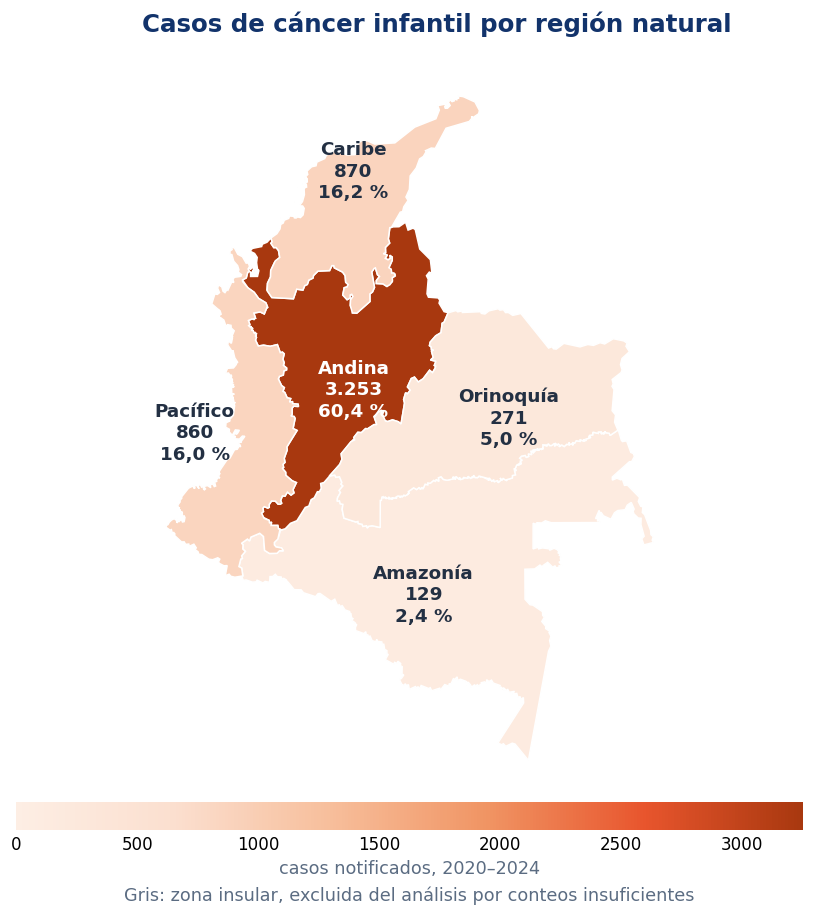

In [30]:
casos_zona = DataE.groupby("zona").casos.sum().to_dict()
total = sum(casos_zona.values())

fig, ax = plt.subplots(figsize=(7.5, 8.4))
etq = {z: f"{REGION[z]}\n{v:,}".replace(",", ".")
          + "\n" + f"{100*v/total:.1f} %".replace(".", ",")
       for z, v in casos_zona.items()}
norma = dibujar_mapa(ax, casos_zona, vmin=0, etiquetas=etq, tam_etq=12)

cb = fig.colorbar(plt.cm.ScalarMappable(cmap=RAMPA, norm=norma), ax=ax,
                  orientation="horizontal", fraction=0.04, pad=0.02, aspect=28)
cb.outline.set_visible(False); cb.ax.tick_params(labelsize=11, length=0)
cb.set_label("casos notificados, 2020–2024\nGris: zona insular, excluida del análisis por conteos insuficientes",
             fontsize=11.5, color=APAGADO, linespacing=1.6)

ax.set_title("Casos de cáncer infantil por región natural",
             fontsize=16, weight="bold", color=NAVY, loc="left", pad=14)
fig.tight_layout()
fig.savefig("figuras/mapa1_casos_por_zona.png", bbox_inches="tight")
plt.show()

### Mapa 2 · Lo que dice el modelo

El mapa anterior muestra el dato crudo; este muestra el resultado del modelo. Cada zona
lleva su **razón de tasas** frente a la Amazonía, que es la categoría de referencia y por
eso vale 1. Entre paréntesis, el intervalo de confianza del 95 %.

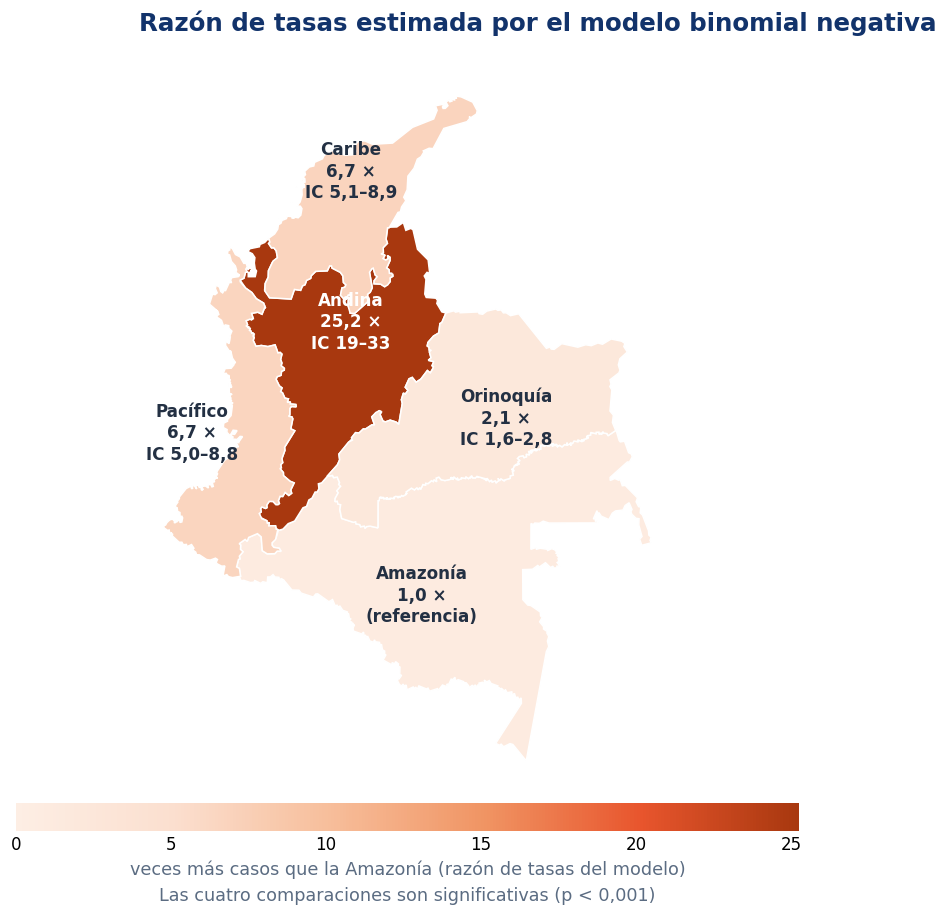

In [31]:
irr_zona = {"AMAZ": 1.0}
ic_zona = {"AMAZ": None}
for clave, cod in [("zonaAND", "AND"), ("zonaCAR", "CAR"),
                   ("zonaORIN", "ORIN"), ("zonaPACF", "PACF")]:
    irr_zona[cod] = float(irr.loc[clave, "IRR"])
    ic_zona[cod] = (float(irr.loc[clave, "IC 95% inf"]), float(irr.loc[clave, "IC 95% sup"]))

fig, ax = plt.subplots(figsize=(7.5, 8.4))
etq = {}
for z, v in irr_zona.items():
    if ic_zona[z] is None:
        etq[z] = f"{REGION[z]}\n1,0 ×\n(referencia)"
    else:
        lo, hi = ic_zona[z]
        fmt = (lambda x: f"{x:.0f}") if hi >= 10 else (lambda x: f"{x:.1f}")
        etq[z] = (f"{REGION[z]}\n{v:.1f} ×\nIC {fmt(lo)}–{fmt(hi)}").replace(".", ",")
norma = dibujar_mapa(ax, irr_zona, vmin=0, etiquetas=etq, tam_etq=11,
                     ajuste_extra={**AJUSTE, "AND": (0, 150_000)})

cb = fig.colorbar(plt.cm.ScalarMappable(cmap=RAMPA, norm=norma), ax=ax,
                  orientation="horizontal", fraction=0.04, pad=0.02, aspect=28)
cb.outline.set_visible(False); cb.ax.tick_params(labelsize=11, length=0)
cb.set_label("veces más casos que la Amazonía (razón de tasas del modelo)\nLas cuatro comparaciones son significativas (p < 0,001)",
             fontsize=11.5, color=APAGADO, linespacing=1.6)

ax.set_title("Razón de tasas estimada por el modelo binomial negativa",
             fontsize=16, weight="bold", color=NAVY, loc="left", pad=14)
fig.tight_layout()
fig.savefig("figuras/mapa2_irr_por_zona.png", bbox_inches="tight")
plt.show()

### Mapa 3 · Qué pasó con el tiempo

Un mapa por año, todos en la misma escala de color. Si el año importara, los mapas se
verían distintos entre sí. Se ven iguales, y eso es exactamente lo que dice el coeficiente
del año en el modelo: p = 0,352.

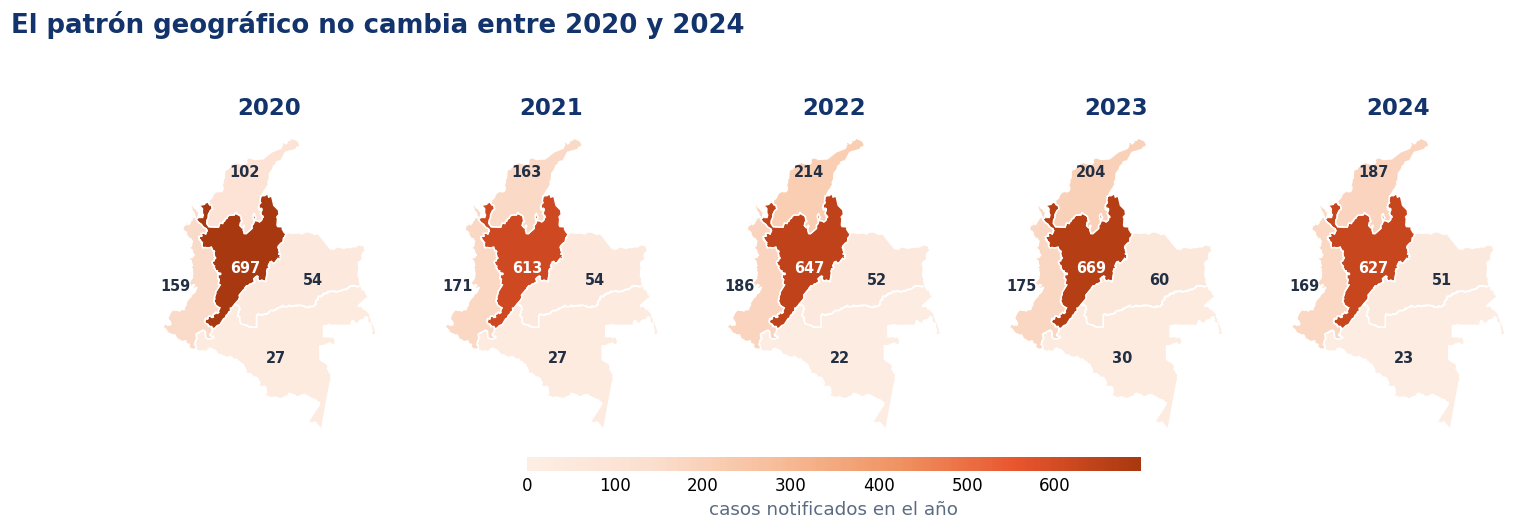

Casos por zona y año:


zona,AMAZ,AND,CAR,ORIN,PACF
anno,,,,,
2020,27,697,102,54,159
2021,27,613,163,54,171
2022,22,647,214,52,186
2023,30,669,204,60,175
2024,23,627,187,51,169


In [32]:
por_anio = DataE.groupby(["anno", "zona"]).casos.sum().unstack()
vmax = por_anio.max().max()

fig, axes = plt.subplots(1, 5, figsize=(16, 4.6))
for ax, anio in zip(axes, sorted(DataE.anno.unique())):
    valores = por_anio.loc[anio].to_dict()
    dibujar_mapa(ax, valores, vmin=0, vmax=vmax,
                 etiquetas={z: f"{v:,}".replace(",", ".") for z, v in valores.items()},
                 tam_etq=9.5)
    ax.set_title(str(anio), fontsize=15, weight="bold", color=NAVY, pad=8)

cb = fig.colorbar(plt.cm.ScalarMappable(cmap=RAMPA, norm=Normalize(0, vmax)),
                  ax=axes, orientation="horizontal", fraction=0.035, pad=0.04, aspect=45)
cb.outline.set_visible(False); cb.ax.tick_params(labelsize=11, length=0)
cb.set_label("casos notificados en el año", fontsize=12, color=APAGADO)

fig.suptitle("El patrón geográfico no cambia entre 2020 y 2024",
             fontsize=17, weight="bold", color=NAVY, x=0.045, ha="left", y=1.02)
fig.savefig("figuras/mapa3_por_anio.png", bbox_inches="tight")
plt.show()

print("Casos por zona y año:")
display(por_anio)

## 9. El tablero

Las tablas y los mapas anteriores son la evidencia; el tablero es la forma de mostrarla.
Esta sección lo **construye desde aquí**: toma los resultados que acaban de calcularse
—los mismos objetos `DataE`, `m_bn`, `irr`, `m_ols` y `traza`— y escribe con ellos
`dashboard/index.html`, una página de una sola pieza que se abre con doble clic, funciona sin
internet y se publica en GitHub Pages.

La idea es que no haya dos verdades. Si mañana llega la vigencia 2025 y el cuaderno se
vuelve a ejecutar, el tablero queda actualizado en el mismo paso: no hay ninguna cifra
escrita a mano dentro del HTML.

```
dashboard/_plantilla.html   el diseño: estructura, estilos y los gráficos en JavaScript
        +
   resultados de este cuaderno  →  datos.json incrustado
        +
dashboard/logo_gemma.png    incrustado en base64
        ▼
dashboard/index.html        el tablero, en un solo archivo
```

### 9.1 Los datos que va a leer el tablero

Un único diccionario con todo lo que la página necesita: los 250 registros, los coeficientes del modelo con sus intervalos, los índices de ajuste, la comparación con la regresión lineal y la trazabilidad.

In [33]:
ic_bn = m_bn.conf_int()
modelo_web = {}
for i, clave in enumerate(["Intercept", "AND", "CAR", "ORIN", "PACF", "anno"]):
    modelo_web[clave] = {
        "coef": float(m_bn.params.iloc[i]), "ee": float(m_bn.bse.iloc[i]),
        "z": float(m_bn.tvalues.iloc[i]), "p": float(m_bn.pvalues.iloc[i]),
        "irr": float(np.exp(m_bn.params.iloc[i])),
        "ic": [float(np.exp(ic_bn.iloc[i, 0])), float(np.exp(ic_bn.iloc[i, 1]))],
    }

comparacion_web = [
    {"zona": z,
     "ols": [float(pred.loc[i, "Prediction"]), float(pred.loc[i, "2.5%"]), float(pred.loc[i, "97.5%"])],
     "bn":  [float(pred_bn.loc[i, "est"]), float(pred_bn.loc[i, "inf"]), float(pred_bn.loc[i, "sup"])]}
    for i, z in enumerate(ZONAS)]

datos_web = {
    "filas": DataE.values.tolist(),
    "columnas": list(DataE.columns),
    "zonas": {z: REGION[z] for z in ZONAS},
    "edades": {"e<1": "menores de 1", "e1-5": "1 a 5", "e5-9": "6 a 9",
               "e9-14": "10 a 14", "e14-18": "15 a 17"},
    "orden_edad": ["e<1", "e1-5", "e5-9", "e9-14", "e14-18"],
    "modelo": modelo_web,
    "ajuste": {"theta": THETA, "aic": float(AIC), "bic": float(BIC), "r2n": float(R2N),
               "dev0": float(m_bn.null_deviance), "dev": float(m_bn.deviance),
               "rmse": float(RMSE)},
    "ols": {"r2": float(m_ols.rsquared), "r2aj": float(m_ols.rsquared_adj),
            "f": float(m_ols.fvalue), "pred": comparacion_web},
    "traza": traza.fillna("").values.tolist(),
}

print(f"Registros para el explorador : {len(datos_web['filas'])}")
print(f"Términos del modelo          : {len(modelo_web)}")
print(f"Pasos de trazabilidad        : {len(datos_web['traza'])}")

Registros para el explorador : 250
Términos del modelo          : 6
Pasos de trazabilidad        : 7


### 9.2 El mapa, convertido a trazos de SVG

El mismo `zonas_colombia.geojson` de la sección 8, pero ahora las coordenadas en metros
(EPSG:3116) se pasan a coordenadas de pantalla y cada región queda como una cadena de
trazo `d`, que es lo que entiende un navegador. Así el tablero dibuja el mapa sin cargar
ninguna librería de mapas.

In [34]:
continental = [f for f in MAPA["features"] if f["properties"]["zona"] != "INS"]

def contornos(f):
    g = f["geometry"]
    return [g["coordinates"]] if g["type"] == "Polygon" else g["coordinates"]

xs = [p[0] for f in continental for poly in contornos(f) for p in poly[0]]
ys = [p[1] for f in continental for poly in contornos(f) for p in poly[0]]
x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)

ANCHO_SVG = 1000.0
escala = ANCHO_SVG / (x1 - x0)
ALTO_SVG = round((y1 - y0) * escala, 1)

def a_pantalla(x, y):
    "Metros -> píxeles del lienzo. El eje y se invierte: en pantalla crece hacia abajo."
    return round((x - x0) * escala, 1), round((y1 - y) * escala, 1)

# Igual que en los mapas de matplotlib, algunas etiquetas se corren un poco (en píxeles)
AJUSTE_SVG = {"PACF": (-135, 40), "CAR": (0, -60), "AND": (0, 20)}

zonas_svg = []
for f in continental:
    trazo = []
    for poly in contornos(f):
        anillo = poly[0]
        px, py = a_pantalla(*anillo[0])
        trazo.append(f"M{px} {py}")
        for punto in anillo[1:]:
            px, py = a_pantalla(*punto)
            trazo.append(f"L{px} {py}")
        trazo.append("Z")
    ex, ey = a_pantalla(f["properties"]["etq_x"], f["properties"]["etq_y"])
    dx, dy = AJUSTE_SVG.get(f["properties"]["zona"], (0, 0))
    zonas_svg.append({"zona": f["properties"]["zona"], "nombre": f["properties"]["nombre"],
                      "d": "".join(trazo), "ex": ex + dx, "ey": ey + dy})

datos_web["mapa"] = {"ancho": ANCHO_SVG, "alto": ALTO_SVG, "zonas": zonas_svg}

print(f"Lienzo del mapa: {ANCHO_SVG:.0f} × {ALTO_SVG:.0f}")
for z in zonas_svg:
    print(f"   {z['nombre']:<10} {len(z['d']):>6} caracteres de trazo")

Lienzo del mapa: 1000 × 1363
   Amazonía     5894 caracteres de trazo
   Andina       3782 caracteres de trazo
   Caribe       2399 caracteres de trazo
   Orinoquía    3421 caracteres de trazo
   Pacífico     4646 caracteres de trazo


### 9.3 Buscar la plantilla

La plantilla y el logo viven en el repositorio. Esta celda los localiza sola: mira en las
carpetas donde suelen estar, busca en todo el proyecto por si la carpeta tiene otro
nombre, actualiza la copia local con `git pull` (útil cuando el cuaderno se clonó **antes**
de subir los archivos, que es la causa más común del error `FileNotFoundError`) y, como
último recurso, los descarga directamente de GitHub.

In [35]:
import base64, glob, subprocess, urllib.request

CRUDO = ("https://raw.githubusercontent.com/MariaClareth/"
         "Monitoreo-del-cancer-infantil-en-Colombia/main")

def buscar(nombre):
    "Devuelve la ruta del archivo, lo busque donde lo busque."
    for carpeta in ["dashboard", "docs", "tablero", "."]:
        ruta = os.path.join(carpeta, nombre)
        if os.path.exists(ruta):
            return ruta
    halladas = glob.glob(f"**/{nombre}", recursive=True)
    return halladas[0] if halladas else None

def traer(nombre):
    "Si no está en la copia local, se actualiza el repositorio y si no se descarga."
    ruta = buscar(nombre)
    if ruta:
        return ruta
    print(f"   {nombre} no está en la copia local; actualizando con git pull …")
    subprocess.run(["git", "pull", "-q", "--rebase"], capture_output=True)
    ruta = buscar(nombre)
    if ruta:
        return ruta
    os.makedirs("dashboard", exist_ok=True)
    for carpeta in ["dashboard", "docs"]:
        try:
            destino = f"dashboard/{nombre}"
            urllib.request.urlretrieve(f"{CRUDO}/{carpeta}/{nombre}", destino)
            print(f"   descargado de GitHub: {carpeta}/{nombre}")
            return destino
        except Exception:
            continue
    return None

ruta_plantilla = traer("_plantilla.html")
ruta_logo = traer("logo_gemma.png")

if ruta_plantilla is None:
    raise FileNotFoundError(
        "No se encontró _plantilla.html. Verificar que esté subida al repositorio "
        "(carpeta dashboard/) y volver a ejecutar esta celda.")

CARPETA_TABLERO = os.path.dirname(ruta_plantilla) or "."
RUTA_TABLERO = os.path.join(CARPETA_TABLERO, "index.html")
print(f"Plantilla: {ruta_plantilla}")
print(f"Logo     : {ruta_logo if ruta_logo else 'no encontrado (el tablero saldrá sin logo)'}")

Plantilla: dashboard/_plantilla.html
Logo     : dashboard/logo_gemma.png


### 9.4 Armar el archivo

A la plantilla se le inyectan los datos y el logo. El logo va en base64 dentro del propio HTML para que el tablero siga siendo un solo archivo: se puede enviar por correo o proyectar en la feria sin conexión.

In [36]:
import re

plantilla = open(ruta_plantilla, encoding="utf-8").read()

tablero = plantilla.replace(
    "__DATOS__", json.dumps(datos_web, ensure_ascii=False, separators=(",", ":")))

if ruta_logo:
    logo64 = "data:image/png;base64," + base64.b64encode(open(ruta_logo, "rb").read()).decode()
    tablero = tablero.replace("__LOGO__", logo64)
    peso_logo = f"{len(logo64)/1024:,.1f} KB en base64"
else:
    # sin logo disponible, se quitan los bloques que lo muestran
    tablero = re.sub(r'<div class="sello">.*?</div>\s*', "", tablero, flags=re.S)
    peso_logo = "no incluido"

assert "__DATOS__" not in tablero and "__LOGO__" not in tablero, "quedó algún marcador sin reemplazar"

with open(RUTA_TABLERO, "w", encoding="utf-8") as f:
    f.write(tablero)

print(f"{RUTA_TABLERO} escrito: {os.path.getsize(RUTA_TABLERO)/1024:,.1f} KB")
print("   · sin llamadas a servidores: los datos van dentro del archivo")
print("   · logo:", peso_logo)

if CARPETA_TABLERO != "dashboard":
    print(f"\nAviso: el tablero quedó en '{CARPETA_TABLERO}/', no en 'dashboard/'.")
    print("Conviene subirlo a dashboard/ para que GitHub Pages lo publique.")

dashboard/index.html escrito: 158.9 KB
   · sin llamadas a servidores: los datos van dentro del archivo
   · logo: 49.0 KB en base64


### 9.5 Verlo aquí mismo

El tablero se muestra dentro del cuaderno. Para verlo completo conviene abrirlo aparte: es una página larga.

In [37]:
from IPython.display import IFrame, display, HTML

display(HTML('<p style="font:14px system-ui">Vista previa del tablero '
             '(desplazarse dentro del marco):</p>'))
display(IFrame(src=RUTA_TABLERO, width="100%", height=620))

### 9.6 Descargarlo o publicarlo

En Colab, esta celda baja el archivo al computador. Para publicarlo en internet se sube el
`index.html` generado a la carpeta `dashboard/` del repositorio. GitHub Pages, en su modo
simple, solo sirve la raíz o una carpeta llamada `docs`; por eso el repositorio incluye el
flujo `.github/workflows/pages.yml`, que publica `dashboard/` en cada subida. Basta con
poner *Settings → Pages → Source* en **GitHub Actions**.

In [38]:
try:
    from google.colab import files
    files.download(RUTA_TABLERO)
    print("Descargando", RUTA_TABLERO, "…")
except ImportError:
    print("Fuera de Colab: el archivo quedó en", os.path.abspath(RUTA_TABLERO))

Fuera de Colab: el archivo quedó en /tmp/claude-0/-home-claude/f76aee50-d0de-5251-b10b-51f1373a8a85/scratchpad/Monitoreo-del-cancer-infantil-en-Colombia/dashboard/index.html


## 10. Resumen y exportación

In [39]:
R = {
    "n_registros": int(len(DataE)), "n_casos": int(DataE.casos.sum()),
    "theta": THETA,
    "coeficientes": {k: float(v) for k, v in zip(nombres, m_bn.params.values)},
    "irr_zona": {NOMBRE_ZONA[k]: float(irr.loc[k, "IRR"]) for k in NOMBRE_ZONA},
    "p_anno": float(irr.loc["anno", "p"]),
    "desviacion_nula": float(m_bn.null_deviance), "desviacion_residual": float(m_bn.deviance),
    "AIC": float(AIC), "AICc": float(AICc), "BIC": float(BIC),
    "R2_nagelkerke": float(R2N), "RMSE": float(RMSE),
    "ols_r2": float(m_ols.rsquared), "ols_r2_ajustado": float(m_ols.rsquared_adj),
    "ols_zonas_con_ic_negativo": negativas.zona.tolist(),
}

resumen = pd.DataFrame([
    ("Casos analizados", f"{R['n_casos']:,}".replace(",", ".") + f" en {R['n_registros']} registros"),
    ("Zona Andina frente a la Amazonía", f"{R['irr_zona']['Andina']:.1f} × (p < 0,001)"),
    ("Caribe frente a la Amazonía", f"{R['irr_zona']['Caribe']:.1f} × (p < 0,001)"),
    ("Pacífico frente a la Amazonía", f"{R['irr_zona']['Pacífico']:.1f} × (p < 0,001)"),
    ("Orinoquía frente a la Amazonía", f"{R['irr_zona']['Orinoquía']:.1f} × (p < 0,001)"),
    ("Efecto del año", f"no significativo (p = {R['p_anno']:.3f})"),
    ("R² de Nagelkerke", f"{R['R2_nagelkerke']:.3f}"),
    ("Desviación", f"de {R['desviacion_nula']:.2f} a {R['desviacion_residual']:.2f}"),
    ("Regresión lineal: R²", f"{R['ols_r2']:.3f}"),
    ("Regresión lineal: zonas con intervalo negativo", ", ".join(R["ols_zonas_con_ic_negativo"])),
], columns=["Resultado", "Valor"])
display(resumen)

resumen.to_csv("resultados/resumen.csv", index=False, encoding="utf-8")
tabla.to_csv("resultados/coeficientes_binomial_negativa.csv", encoding="utf-8")
zonas_irr.to_csv("resultados/irr_por_zona.csv", encoding="utf-8")
tols.to_csv("resultados/coeficientes_regresion_lineal.csv", encoding="utf-8")
pred.to_csv("resultados/predicciones_lineal_2020.csv", index=False, encoding="utf-8")
json.dump(R, open("resultados/resultados.json", "w", encoding="utf-8"),
          indent=1, ensure_ascii=False)

print("\nArchivos guardados:")
for c in ["figuras", "resultados"]:
    for f in sorted(os.listdir(c)):
        print(f"   {c}/{f}")

,Resultado,Valor
0,Casos analizados,5.383 en 250 registros
1,Zona Andina frente a la Amazonía,"25.2 × (p < 0,001)"
2,Caribe frente a la Amazonía,"6.7 × (p < 0,001)"
3,Pacífico frente a la Amazonía,"6.7 × (p < 0,001)"
4,Orinoquía frente a la Amazonía,"2.1 × (p < 0,001)"
5,Efecto del año,no significativo (p = 0.352)
6,R² de Nagelkerke,0.970
7,Desviación,de 1054.10 a 272.59
8,Regresión lineal: R²,0.696
9,Regresión lineal: zonas con intervalo negativo,"AMAZ, ORIN"



Archivos guardados:
   figuras/fig1_medias_anno_zona.png
   figuras/fig2_anno_por_zona.png
   figuras/fig3_zona_por_anno.png
   figuras/fig4_edad_por_sexo.png
   figuras/fig5_irr_por_zona.png
   figuras/fig6_lineal_vs_conteo.png
   figuras/mapa1_casos_por_zona.png
   figuras/mapa2_irr_por_zona.png
   figuras/mapa3_por_anio.png
   resultados/coeficientes_binomial_negativa.csv
   resultados/coeficientes_regresion_lineal.csv
   resultados/irr_por_zona.csv
   resultados/predicciones_lineal_2020.csv
   resultados/resultados.json
   resultados/resumen.csv
   resultados/trazabilidad.csv


### Lectura de los resultados

1. **La zona explica casi todo.** Las cuatro comparaciones contra la Amazonía son
   significativas y de magnitud grande: la Andina registra 25 veces más casos.
2. **El año no explica nada.** Su coeficiente no es significativo ni en el modelo de
   conteo (p = 0,352) ni en la regresión lineal, donde ningún año se separa de 2020.
   Entre 2020 y 2024 el patrón geográfico se mantuvo estable.
3. **El modelo de conteo era necesario.** La regresión lineal produce intervalos con
   casos negativos en dos de las cinco zonas. La binomial negativa respeta la naturaleza
   discreta y no negativa del dato.

**Una advertencia al leer estas cifras.** Se analizan conteos de notificación, no tasas de
incidencia. Sin denominadores poblacionales, la diferencia entre zonas refleja también
cuánta población infantil vive en cada una y qué capacidad de diagnóstico y notificación
tiene. Con las proyecciones de población del DANE, este mismo cuaderno permitiría calcular
tasas por 100.000 y razones de incidencia estandarizada.

---

### Referencias

- Venables, W. N. y Ripley, B. D. (2002). *Modern Applied Statistics with S* (4.ª ed.). Springer. (paquete `MASS`)
- Cameron, A. C. y Trivedi, P. K. (2013). *Regression analysis of count data* (2.ª ed.). Cambridge University Press.
- Lüdecke, D. et al. (2021). performance: An R package for assessment, comparison and testing of statistical models. *Journal of Open Source Software*, 6(60), 3139.
- R Core Team (2023). *R: A language and environment for statistical computing*.